## Import library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
import optbinning
import pickle
import joblib

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 500)
warnings.filterwarnings("ignore")

import sys
sys.path.append("../src")

from data_eda.data_eda import *
from data_eda.plot import * 
from features.features_eng import *

(CVXPY) Mar 09 03:02:58 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Mar 09 03:02:58 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')


## Read dataset

In [2]:
data = pd.read_csv("../data/raw/10K_Lending_Club_Loans.csv", encoding='ISO-8859-1')
use_col = pd.read_csv("../data/interim/10K_Lending_Club_Loans.csv", nrows=1).columns.tolist()

print(data.shape)
display(data.head(5))
print(use_col)

(10000, 34)


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,mths_since_last_major_derog,policy_code,is_bad
0,4000,4000,60 months,7.29%,79.76,A,A4,Time Warner Cable,10+ years,MORTGAGE,50000.0,not verified,n,https://www.lendingclub.com/browse/loanDetail....,NaN,medical,Medical,766xx,TX,10.87,0.0,12/1/92,0.0,NaN,NaN,15.0,0.0,12087,12.1,44.0,f,NaN,1,0
1,16000,16000,60 months,18.25%,408.48,F,F1,Ottawa University,< 1 year,RENT,39216.0,not verified,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 04/14/11 > I will be using...,debt_consolidation,My Debt Consolidation Loan,660xx,KS,9.15,0.0,11/1/05,2.0,NaN,NaN,4.0,0.0,10114,64.0,5.0,f,NaN,1,0
2,8700,8700,36 months,7.88%,272.15,A,A5,Kennedy Wilson,4 years,RENT,65000.0,not verified,n,https://www.lendingclub.com/browse/loanDetail....,NaN,credit_card,AP Personal Loan,916xx,CA,11.24,0.0,6/1/70,0.0,NaN,NaN,4.0,0.0,81,0.6,8.0,f,NaN,1,0
3,18000,18000,60 months,11.49%,395.78,B,B4,TOWN OF PLATTEKILL,10+ years,MORTGAGE,57500.0,not verified,n,https://www.lendingclub.com/browse/loanDetail....,NaN,debt_consolidation,Debt Consolidation Loan,124xx,NY,6.18,1.0,9/1/82,0.0,16.0,NaN,6.0,0.0,10030,37.1,23.0,f,NaN,1,0
4,16000,16000,36 months,11.83%,530.15,B,B3,Belmont Correctional,10+ years,MORTGAGE,50004.0,VERIFIED - income,n,https://www.lendingclub.com/browse/loanDetail....,"I want to consolidate my debt, pay for a vacat...",debt_consolidation,consolidate,439xx,OH,19.03,0.0,10/1/99,4.0,NaN,NaN,8.0,0.0,10740,40.4,21.0,f,NaN,1,0


['loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment', 'grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'is_bad']


In [3]:
data_use = data[use_col]

print(data_use.shape)
display(data_use.head(5))

(10000, 22)


,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,is_bad
0,4000,4000,60 months,7.29%,79.76,A,10+ years,MORTGAGE,50000.0,not verified,medical,TX,10.87,0.0,12/1/92,0.0,15.0,0.0,12087,12.1,44.0,0
1,16000,16000,60 months,18.25%,408.48,F,< 1 year,RENT,39216.0,not verified,debt_consolidation,KS,9.15,0.0,11/1/05,2.0,4.0,0.0,10114,64.0,5.0,0
2,8700,8700,36 months,7.88%,272.15,A,4 years,RENT,65000.0,not verified,credit_card,CA,11.24,0.0,6/1/70,0.0,4.0,0.0,81,0.6,8.0,0
3,18000,18000,60 months,11.49%,395.78,B,10+ years,MORTGAGE,57500.0,not verified,debt_consolidation,NY,6.18,1.0,9/1/82,0.0,6.0,0.0,10030,37.1,23.0,0
4,16000,16000,36 months,11.83%,530.15,B,10+ years,MORTGAGE,50004.0,VERIFIED - income,debt_consolidation,OH,19.03,0.0,10/1/99,4.0,8.0,0.0,10740,40.4,21.0,0


## Pre-processing

In [4]:
def transform_cate_col(data):

    data_use = data.copy()

    # Transform cate col to num col
    data_use['emp_length'] = data_use['emp_length'].str.replace(' years', '').str.replace('+', '').str.replace(' year', '')
    data_use['emp_length'] = np.where(data_use['emp_length'] == '< 1',0,data_use['emp_length']).astype(float)

    data_use['earliest_cr_line'] = pd.to_datetime(data_use['earliest_cr_line'])
    data_use['earliest_cr_line'] = (data_use['earliest_cr_line'].max() - data_use['earliest_cr_line']).dt.days/30 # Assume as every app app-in same this on latest date

    data_use['int_rate'] = data_use['int_rate'].str.replace('%', '').astype(float) / 100

    data_use['home_ownership'] = np.where(data_use['home_ownership'].isin(['RENT','MORTGAGE','OWN']), data_use['home_ownership'], 'OTHERS')

    data_use['purpose'] = np.where(data_use['purpose'].isin([
                                                            'medical', 'debt_consolidation', 'credit_card', 'other', 'car',
                                                            'wedding', 'house', 'small_business', 'educational',
                                                            'major_purchase', 'home_improvement', 'vacation', 'moving','renewable_energy'])
                                                            , data_use['purpose'], 'OTHERS')
    
    # This process can be group in bigger region (Next phase)
    data_use = data_use.drop(columns = ['addr_state'])

    return data_use

In [5]:
data_preproc = transform_cate_col(data_use)

data_preproc.head(5)

,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,is_bad
0,4000,4000,60 months,0.0729,79.76,A,10.0,MORTGAGE,50000.0,not verified,medical,10.87,0.0,1010.500000,0.0,15.0,0.0,12087,12.1,44.0,0
1,16000,16000,60 months,0.1825,408.48,F,0.0,RENT,39216.0,not verified,debt_consolidation,9.15,0.0,853.233333,2.0,4.0,0.0,10114,64.0,5.0,0
2,8700,8700,36 months,0.0788,272.15,A,4.0,RENT,65000.0,not verified,credit_card,11.24,0.0,66.966667,0.0,4.0,0.0,81,0.6,8.0,0
3,18000,18000,60 months,0.1149,395.78,B,10.0,MORTGAGE,57500.0,not verified,debt_consolidation,6.18,1.0,1135.300000,0.0,6.0,0.0,10030,37.1,23.0,0
4,16000,16000,36 months,0.1183,530.15,B,10.0,MORTGAGE,50004.0,VERIFIED - income,debt_consolidation,19.03,0.0,927.333333,4.0,8.0,0.0,10740,40.4,21.0,0


In [6]:
missing_report(data_preproc).sort_values(by=['type','unique_value'], ascending=False)

,variable,missing_count,missing_pct,type,unique_value
purpose,purpose,0,0.0000,object,14
grade,grade,0,0.0000,object,7
home_ownership,home_ownership,0,0.0000,object,4
verification_status,verification_status,0,0.0000,object,3
term,term,0,0.0000,object,2
installment,installment,0,0.0000,float64,6381
dti,dti,0,0.0000,float64,2585
annual_inc,annual_inc,1,0.0001,float64,1901
revol_util,revol_util,23,0.0023,float64,1030
earliest_cr_line,earliest_cr_line,5,0.0005,float64,463


## Additional feature

In [7]:
def additional_feature(data):
    data_use = data.copy()
    data_use['loan_amnt_per_installment'] = data_use['loan_amnt'] / data_use['installment']
    data_use['income_to_interest_ratio'] = data_use['annual_inc'] / data_use['loan_amnt']

    return data_use

data_preproc = additional_feature(data_preproc)

data_preproc.head(5)

,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,is_bad,loan_amnt_per_installment,income_to_interest_ratio
0,4000,4000,60 months,0.0729,79.76,A,10.0,MORTGAGE,50000.0,not verified,medical,10.87,0.0,1010.500000,0.0,15.0,0.0,12087,12.1,44.0,0,50.150451,12.500000
1,16000,16000,60 months,0.1825,408.48,F,0.0,RENT,39216.0,not verified,debt_consolidation,9.15,0.0,853.233333,2.0,4.0,0.0,10114,64.0,5.0,0,39.169604,2.451000
2,8700,8700,36 months,0.0788,272.15,A,4.0,RENT,65000.0,not verified,credit_card,11.24,0.0,66.966667,0.0,4.0,0.0,81,0.6,8.0,0,31.967665,7.471264
3,18000,18000,60 months,0.1149,395.78,B,10.0,MORTGAGE,57500.0,not verified,debt_consolidation,6.18,1.0,1135.300000,0.0,6.0,0.0,10030,37.1,23.0,0,45.479812,3.194444
4,16000,16000,36 months,0.1183,530.15,B,10.0,MORTGAGE,50004.0,VERIFIED - income,debt_consolidation,19.03,0.0,927.333333,4.0,8.0,0.0,10740,40.4,21.0,0,30.180138,3.125250


## Feature selection

In [8]:
data_postproc = data_preproc.copy()
drop = list()

print(data_postproc.shape)
data_postproc.head(5)

(10000, 23)


,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,is_bad,loan_amnt_per_installment,income_to_interest_ratio
0,4000,4000,60 months,0.0729,79.76,A,10.0,MORTGAGE,50000.0,not verified,medical,10.87,0.0,1010.500000,0.0,15.0,0.0,12087,12.1,44.0,0,50.150451,12.500000
1,16000,16000,60 months,0.1825,408.48,F,0.0,RENT,39216.0,not verified,debt_consolidation,9.15,0.0,853.233333,2.0,4.0,0.0,10114,64.0,5.0,0,39.169604,2.451000
2,8700,8700,36 months,0.0788,272.15,A,4.0,RENT,65000.0,not verified,credit_card,11.24,0.0,66.966667,0.0,4.0,0.0,81,0.6,8.0,0,31.967665,7.471264
3,18000,18000,60 months,0.1149,395.78,B,10.0,MORTGAGE,57500.0,not verified,debt_consolidation,6.18,1.0,1135.300000,0.0,6.0,0.0,10030,37.1,23.0,0,45.479812,3.194444
4,16000,16000,36 months,0.1183,530.15,B,10.0,MORTGAGE,50004.0,VERIFIED - income,debt_consolidation,19.03,0.0,927.333333,4.0,8.0,0.0,10740,40.4,21.0,0,30.180138,3.125250


### IV

In [9]:
binning_process, iv_summary = iv_score(data_postproc.drop(columns=['is_bad'])
                                        , data_postproc['is_bad']
                                        , max_n_bins=5
                                        , min_bin_size=0.05)

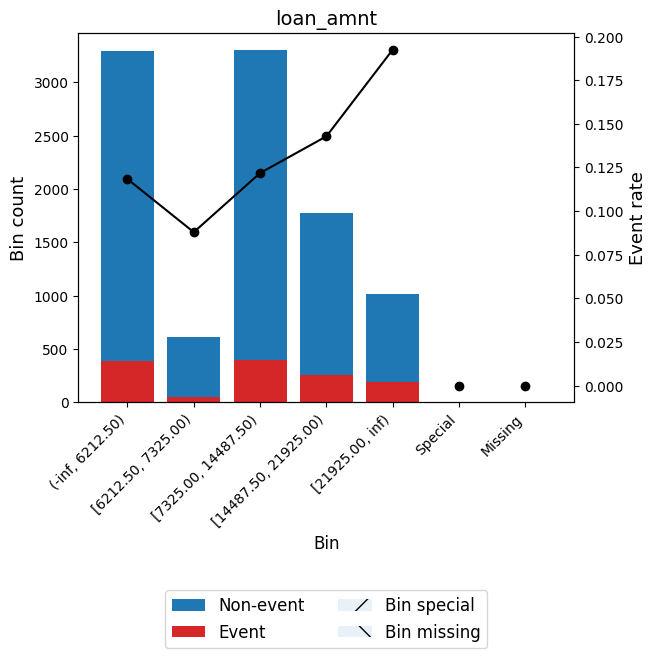

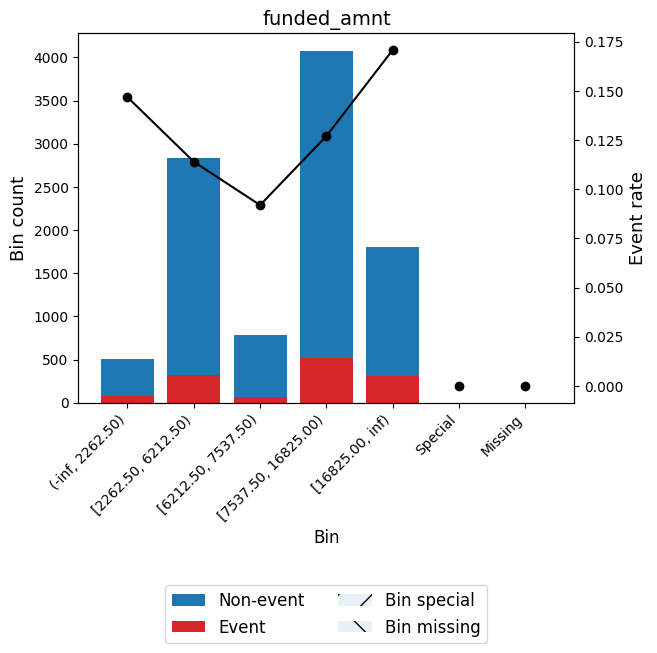

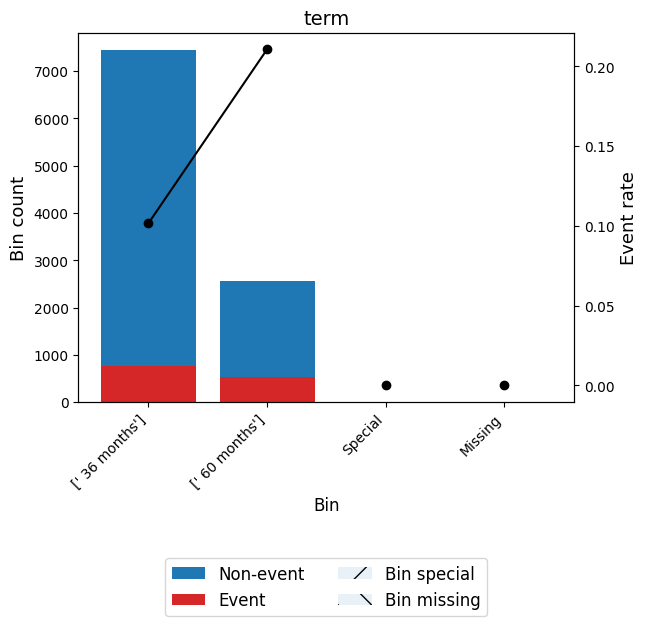

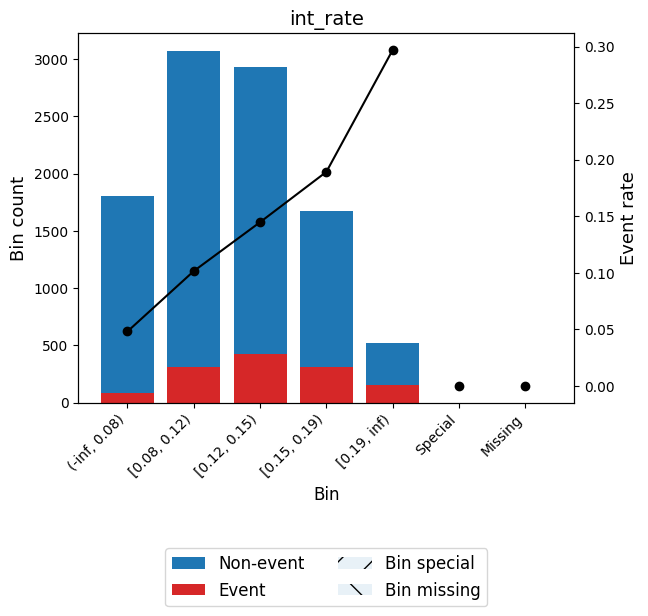

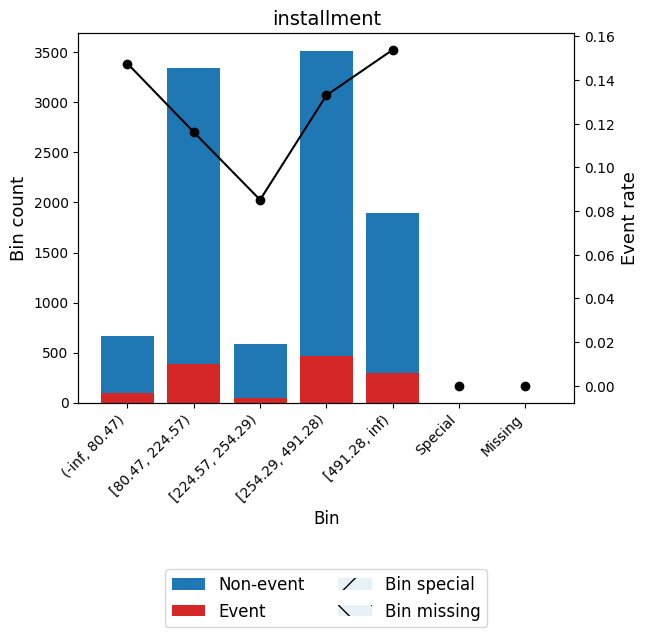

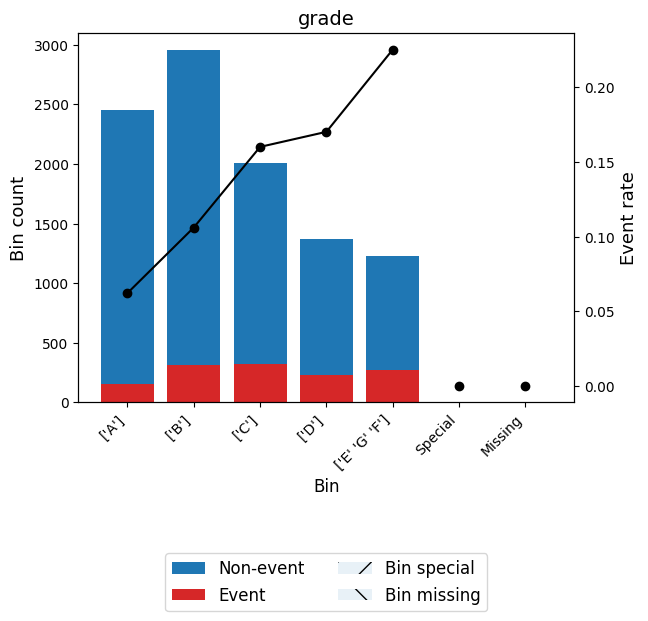

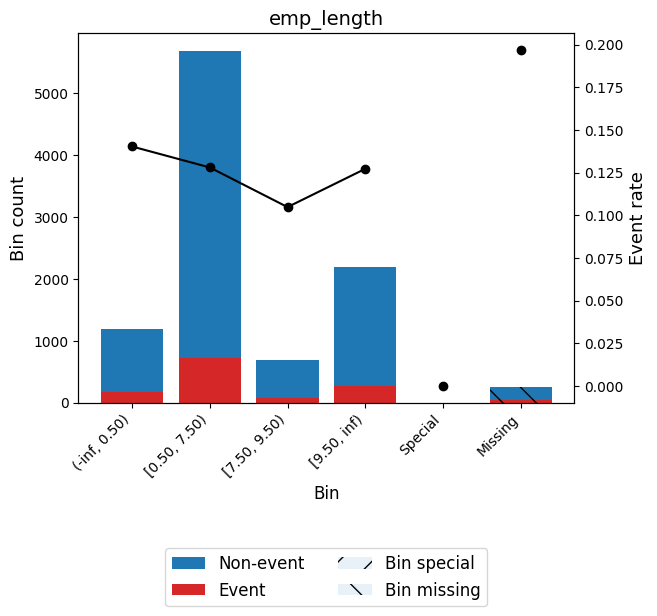

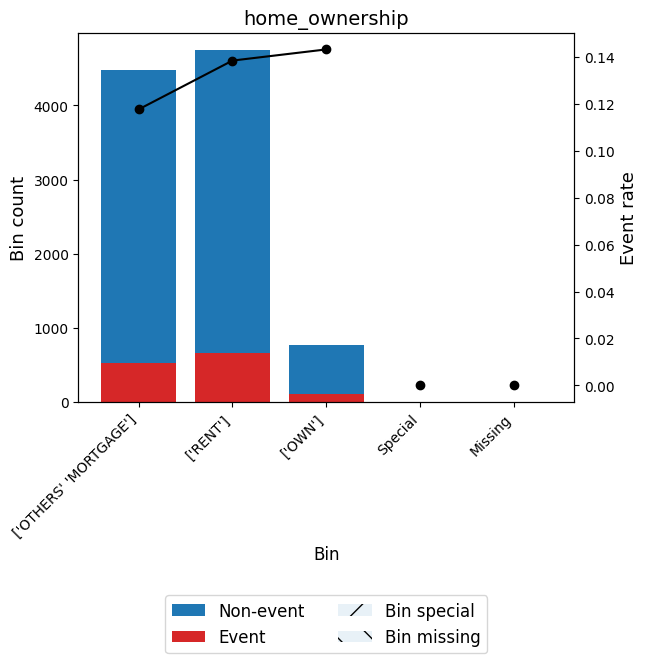

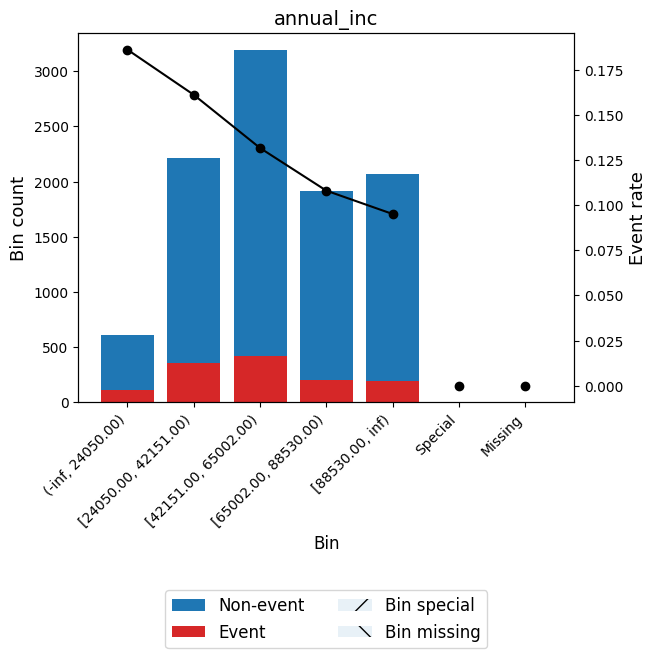

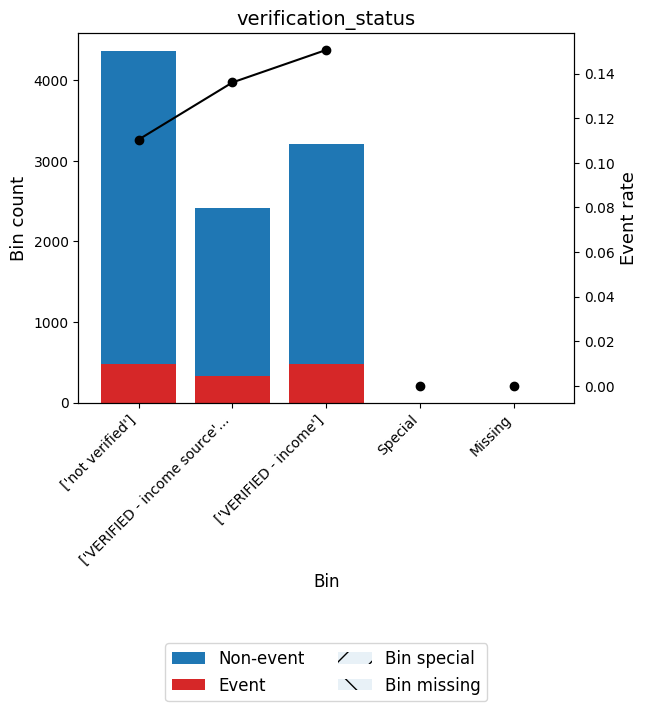

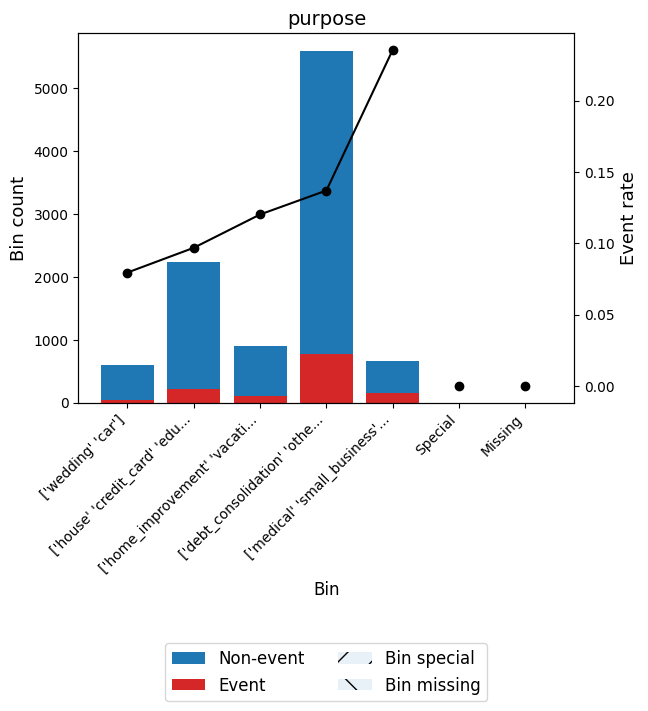

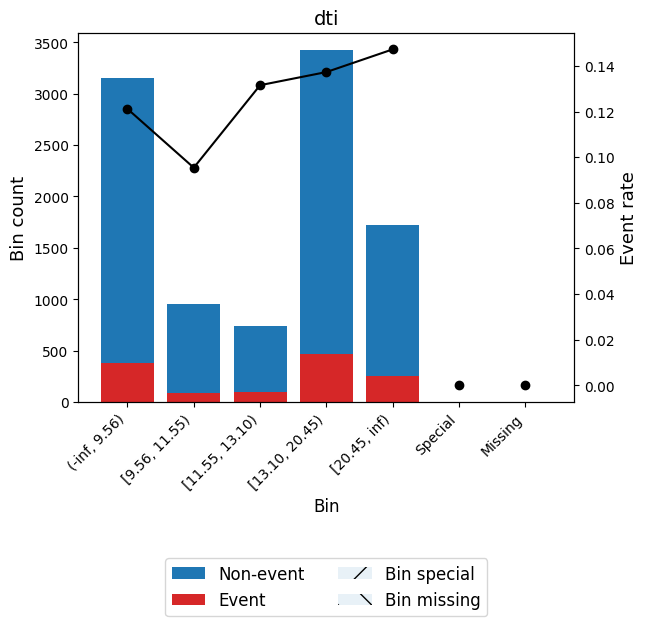

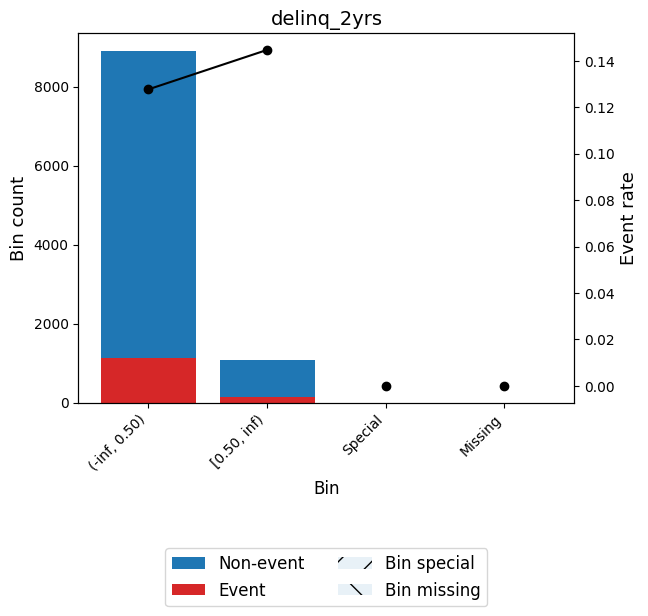

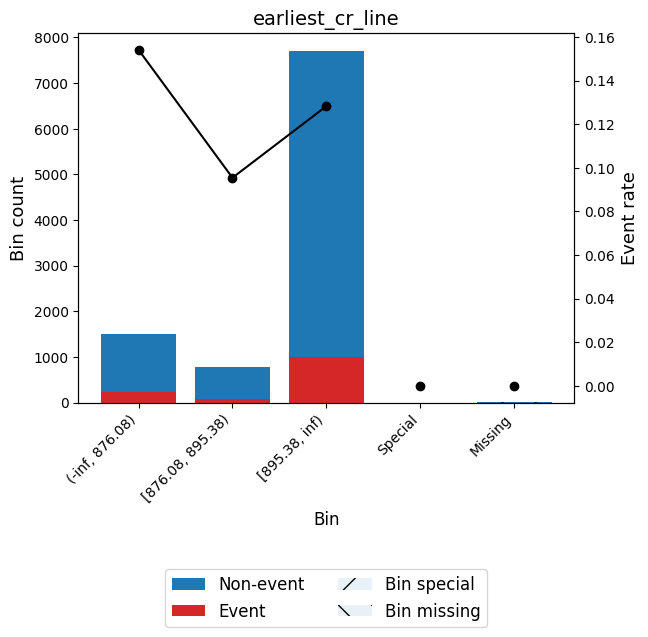

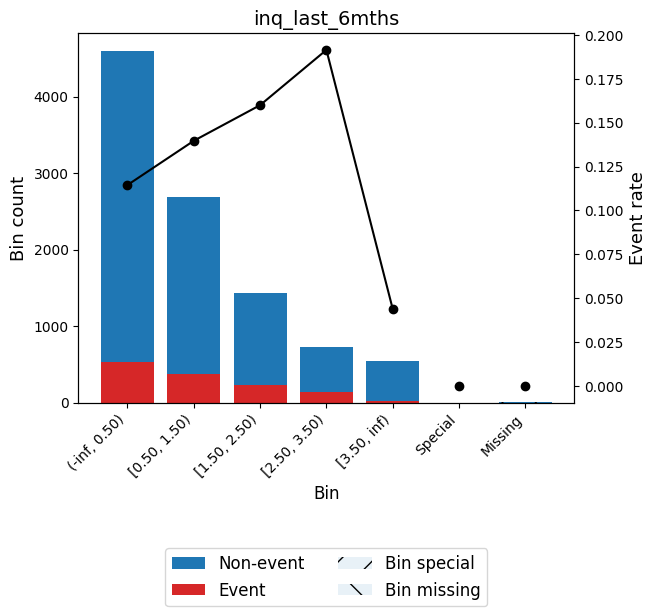

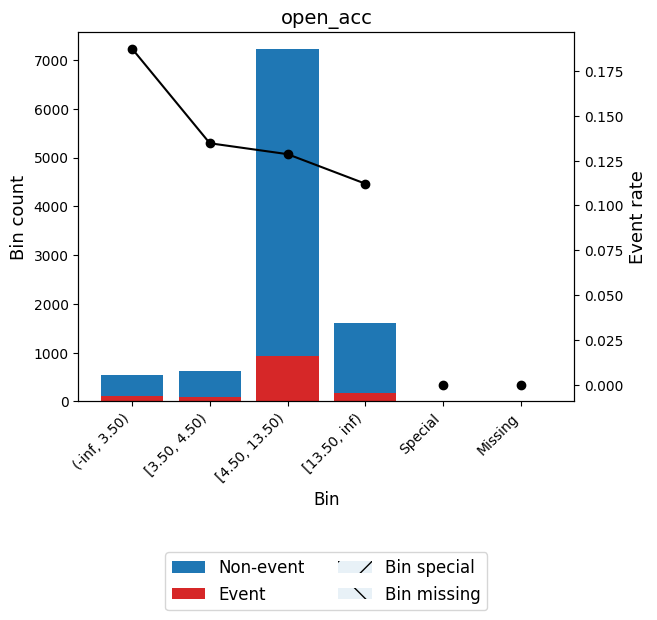

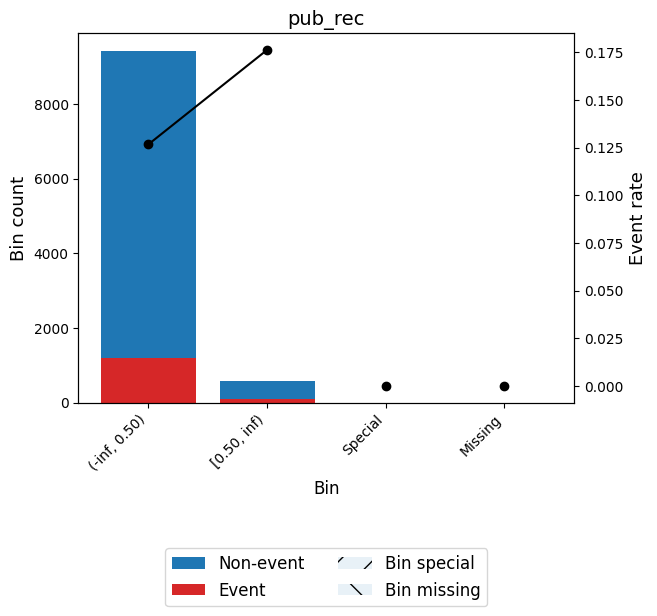

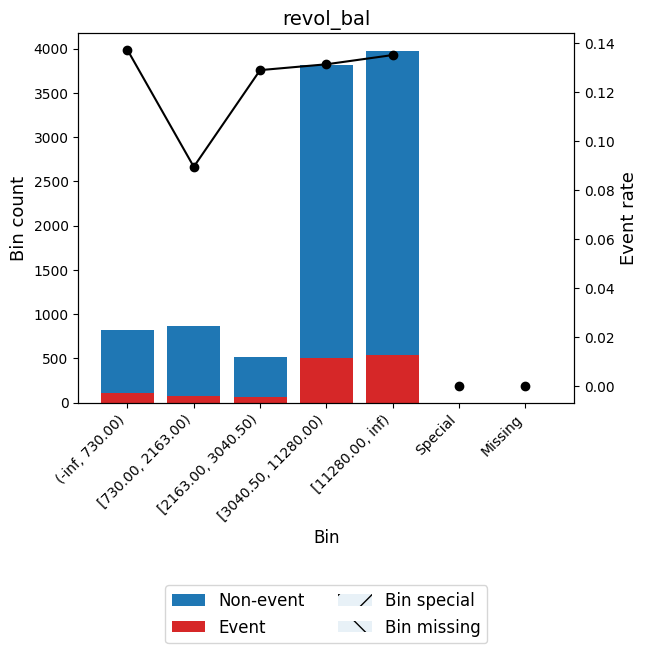

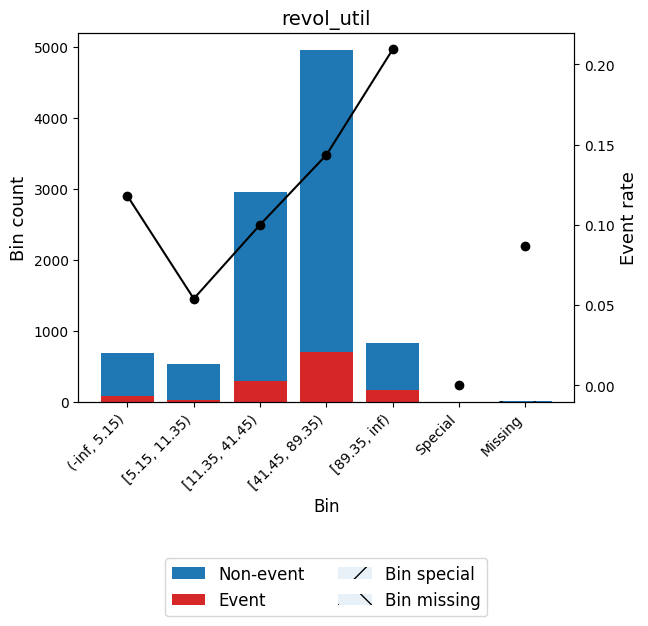

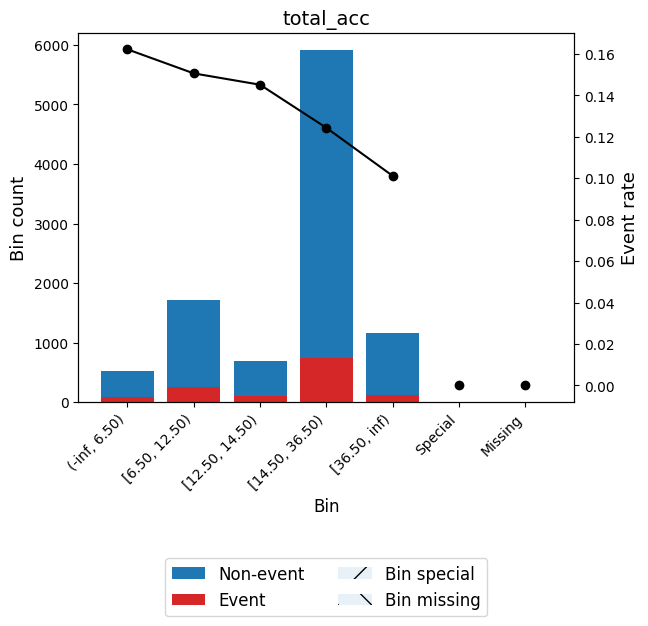

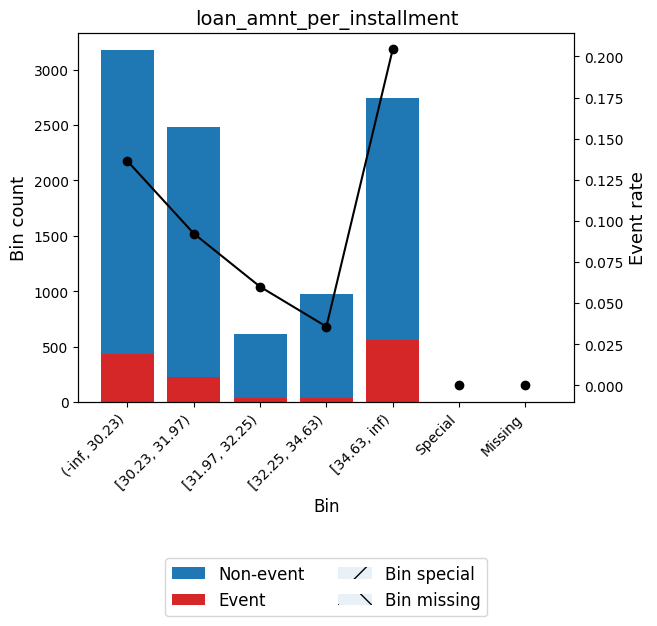

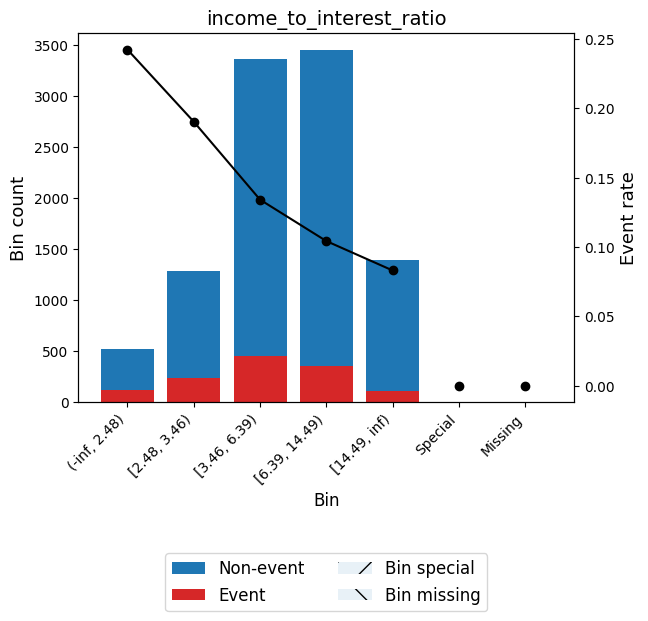

In [10]:
for col in data_postproc.drop(columns = ['is_bad']):
    build = binning_process.get_binned_variable(col)
    bin_df = build.binning_table.build(); bin_df
    build.binning_table.plot(metric = 'event_rate', show_bin_labels=True)

In [11]:
drop.extend(iv_summary[iv_summary['iv'] < 0.02]['name'].tolist())
drop = list(set(drop))

print(drop)
print(len(drop))

['pub_rec', 'dti', 'earliest_cr_line', 'home_ownership', 'emp_length', 'revol_bal', 'delinq_2yrs', 'open_acc']
8


### CORRELATION

In [12]:
selected_features, removed_features = remove_correlated_features(
                                        data_postproc[list(data_postproc.select_dtypes(exclude=['object']))].drop(columns = ['is_bad']),
                                        iv_summary[iv_summary['name'].isin(data_postproc.select_dtypes(exclude=['object']))][['name','iv']],
                                        corr_threshold=0.7
                                    )

print("Selected:", selected_features)
print("Removed:", removed_features)

Selected: ['int_rate', 'loan_amnt_per_installment', 'income_to_interest_ratio', 'revol_util', 'inq_last_6mths', 'annual_inc', 'loan_amnt', 'total_acc', 'dti', 'earliest_cr_line', 'revol_bal', 'emp_length', 'pub_rec', 'delinq_2yrs']
Removed: ['funded_amnt', 'installment', 'open_acc']


In [13]:
drop.extend(removed_features)

drop = list(set(drop))

print(drop)
print(len(drop))

['pub_rec', 'dti', 'earliest_cr_line', 'home_ownership', 'emp_length', 'revol_bal', 'delinq_2yrs', 'funded_amnt', 'installment', 'open_acc']
10


### ANOVA (Optional)

In [14]:
#

### CHI-SQUARE (Optional)

In [15]:
#

## Final drop features

In [16]:
print(drop)
print(len(drop))
data_final = data_postproc.drop(columns=drop)

print(data_final.shape)
data_final.head(5)

['pub_rec', 'dti', 'earliest_cr_line', 'home_ownership', 'emp_length', 'revol_bal', 'delinq_2yrs', 'funded_amnt', 'installment', 'open_acc']
10
(10000, 13)


,loan_amnt,term,int_rate,grade,annual_inc,verification_status,purpose,inq_last_6mths,revol_util,total_acc,is_bad,loan_amnt_per_installment,income_to_interest_ratio
0,4000,60 months,0.0729,A,50000.0,not verified,medical,0.0,12.1,44.0,0,50.150451,12.500000
1,16000,60 months,0.1825,F,39216.0,not verified,debt_consolidation,2.0,64.0,5.0,0,39.169604,2.451000
2,8700,36 months,0.0788,A,65000.0,not verified,credit_card,0.0,0.6,8.0,0,31.967665,7.471264
3,18000,60 months,0.1149,B,57500.0,not verified,debt_consolidation,0.0,37.1,23.0,0,45.479812,3.194444
4,16000,36 months,0.1183,B,50004.0,VERIFIED - income,debt_consolidation,4.0,40.4,21.0,0,30.180138,3.125250


### Plot final features

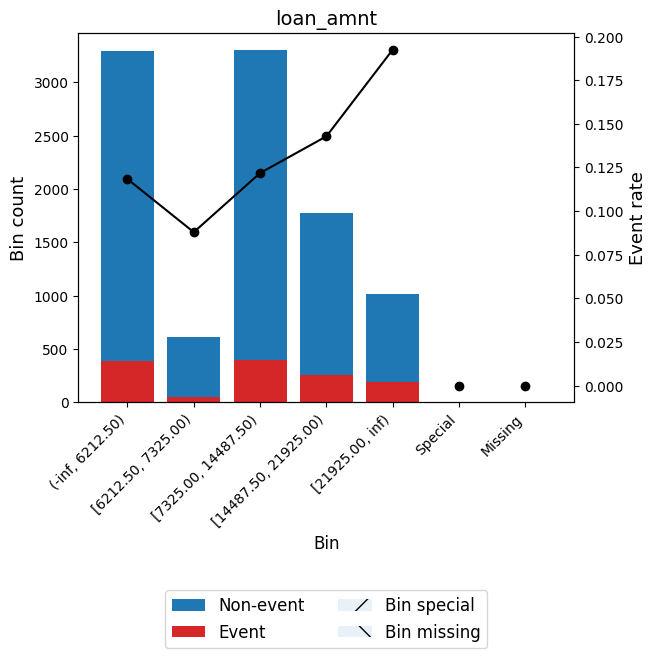

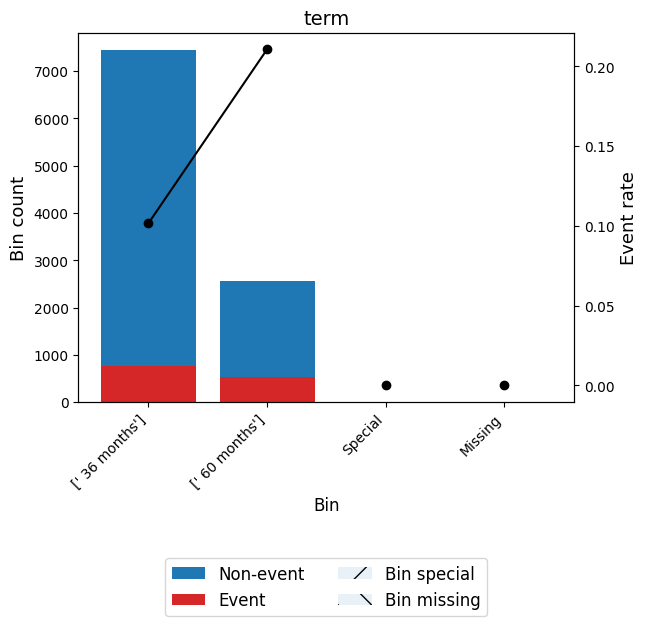

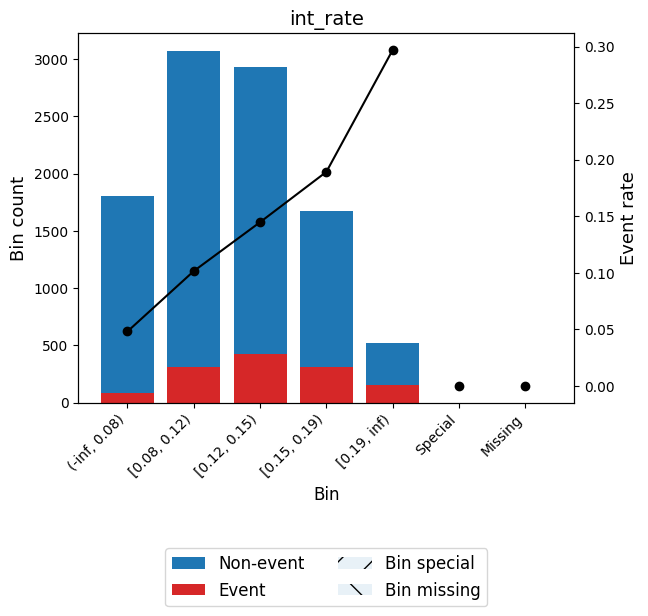

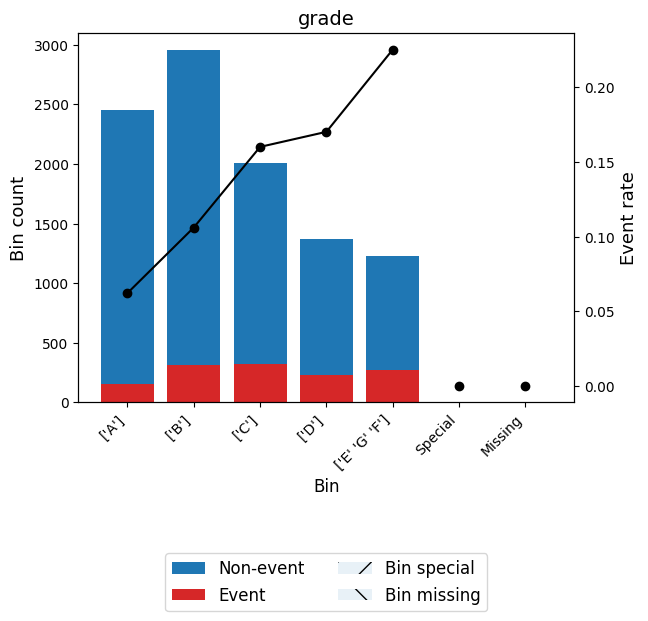

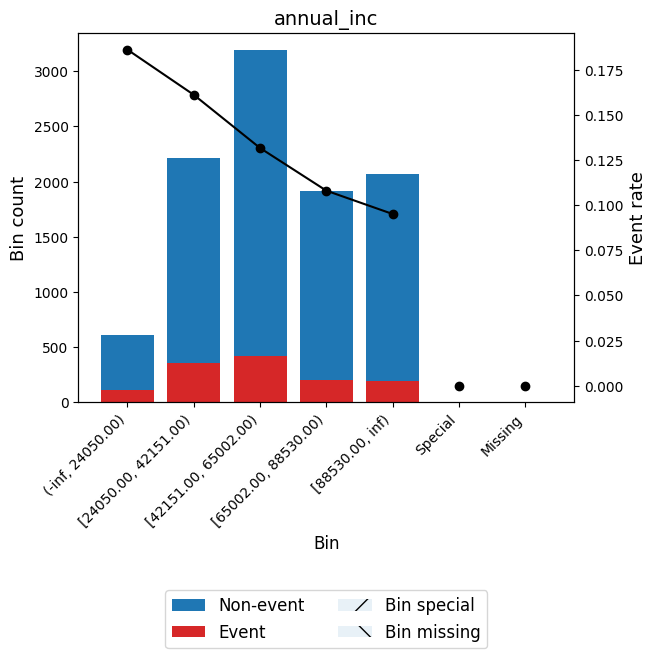

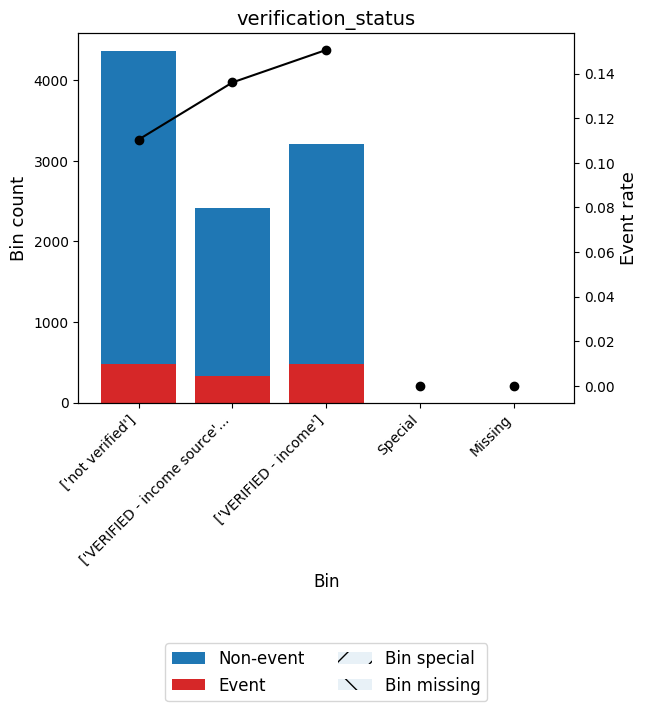

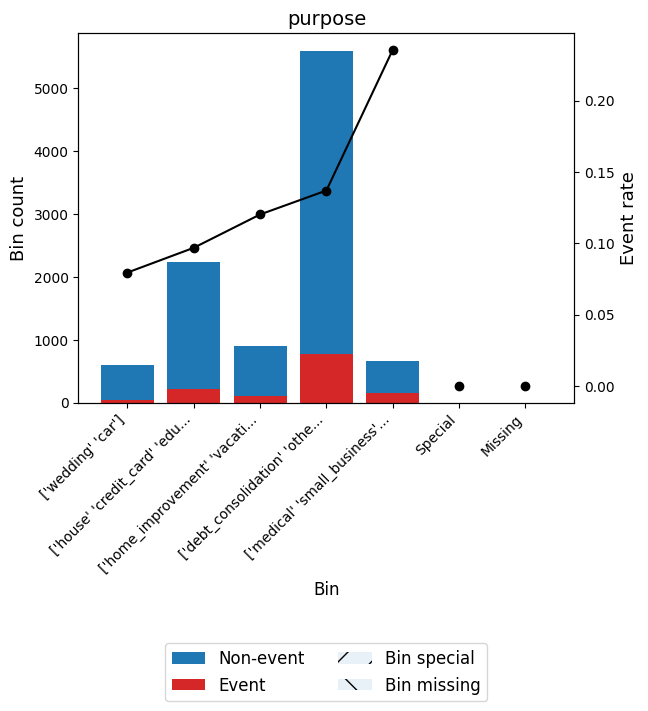

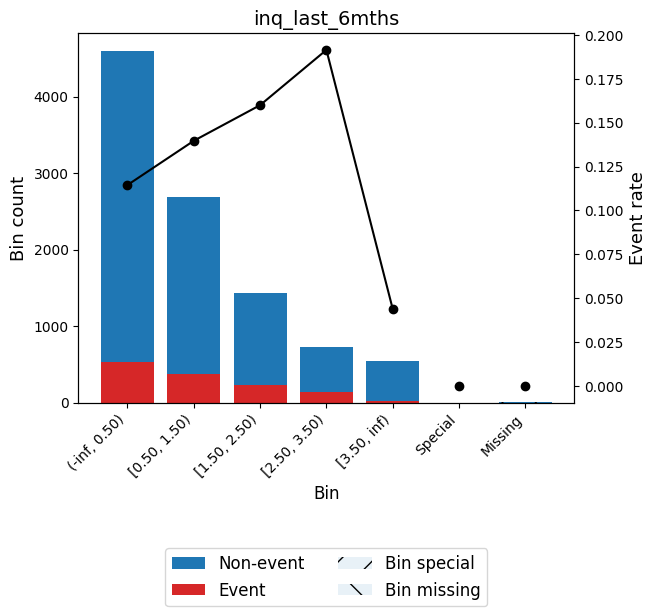

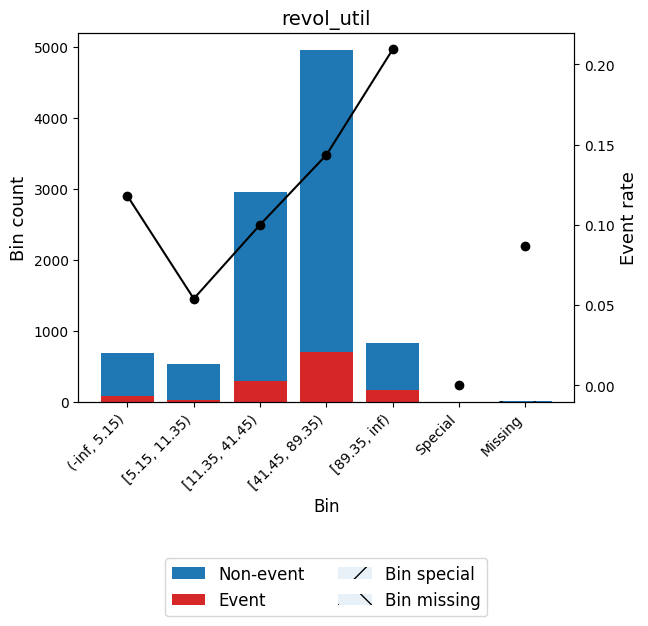

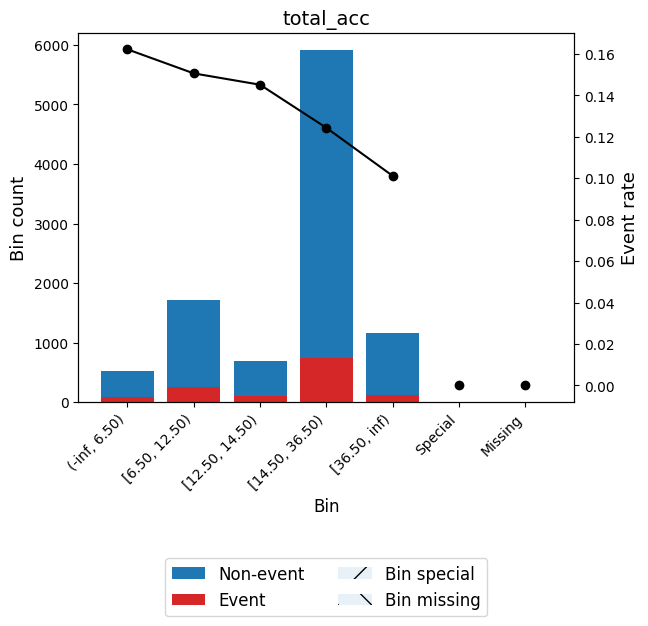

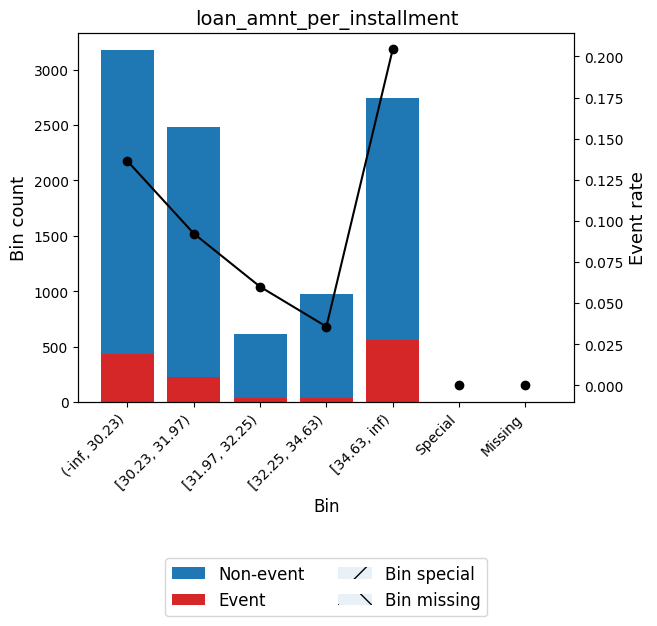

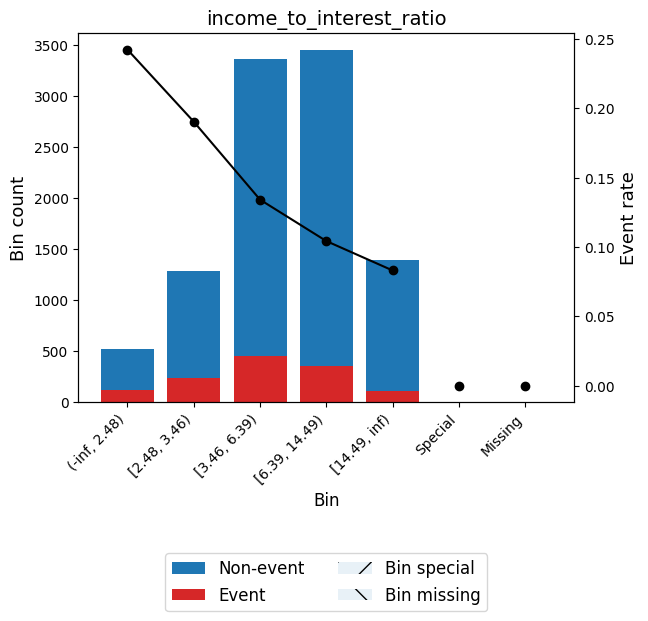

In [17]:
for col in data_final.drop(columns = ['is_bad']):
    build = binning_process.get_binned_variable(col)
    bin_df = build.binning_table.build(); bin_df
    build.binning_table.plot(metric = 'event_rate', show_bin_labels=True)

### Monotonic processing

In [18]:
params_dict = {}
descending_trend = ['loan_amnt_per_installment']
ascending_trend = ['loan_amnt','inq_last_6mths','revol_util']

for col in descending_trend+ascending_trend:
    if col in descending_trend: 
        trend = "descending"
    else: 
        trend = "ascending"
    params_dict[col] = {"max_n_bins":5, "monotonic_trend":trend}

params_dict

{'loan_amnt_per_installment': {'max_n_bins': 5,
  'monotonic_trend': 'descending'},
 'loan_amnt': {'max_n_bins': 5, 'monotonic_trend': 'ascending'},
 'inq_last_6mths': {'max_n_bins': 5, 'monotonic_trend': 'ascending'},
 'revol_util': {'max_n_bins': 5, 'monotonic_trend': 'ascending'}}

In [19]:
binning_process, iv_summary = iv_score(data_final.drop(columns=['is_bad'])
                                        , data_postproc['is_bad']
                                        , max_n_bins=5
                                        , min_bin_size=0.05
                                        , param_dict=params_dict)

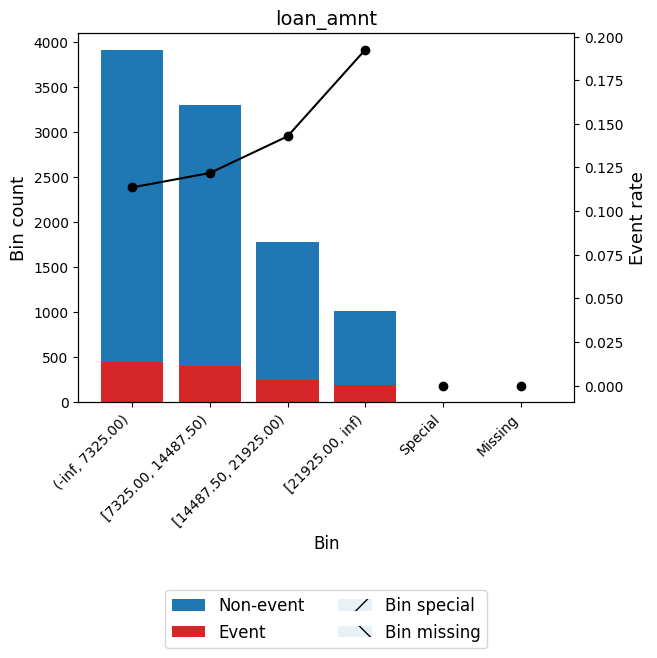

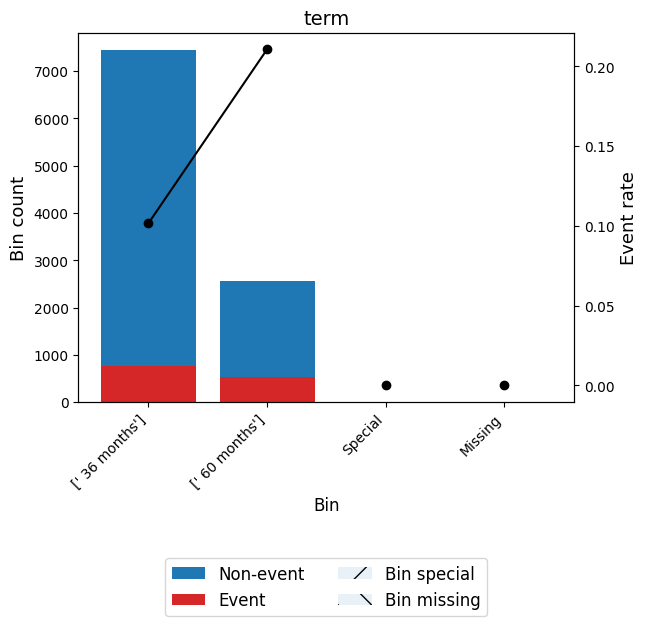

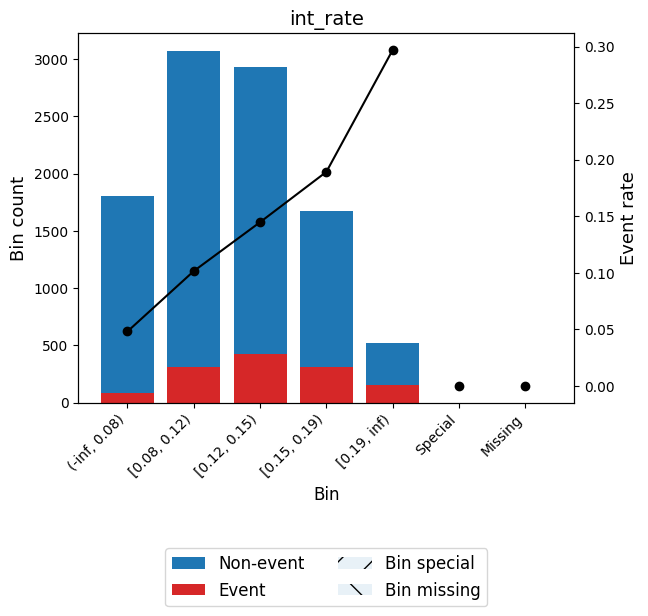

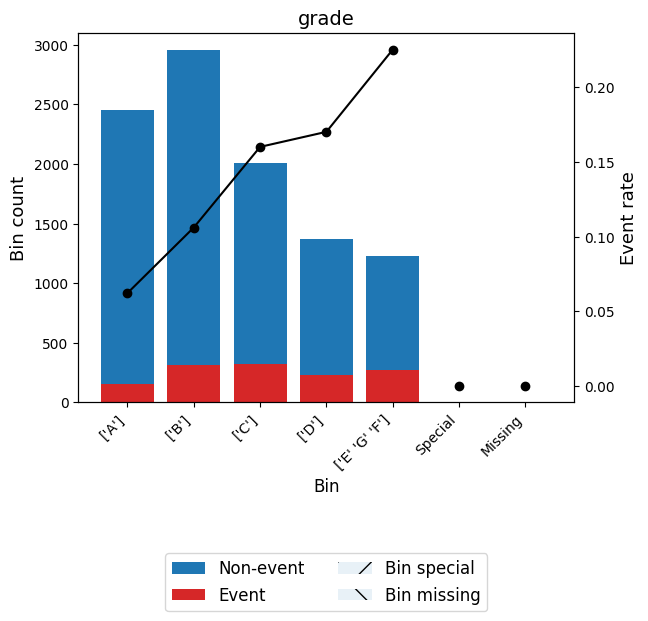

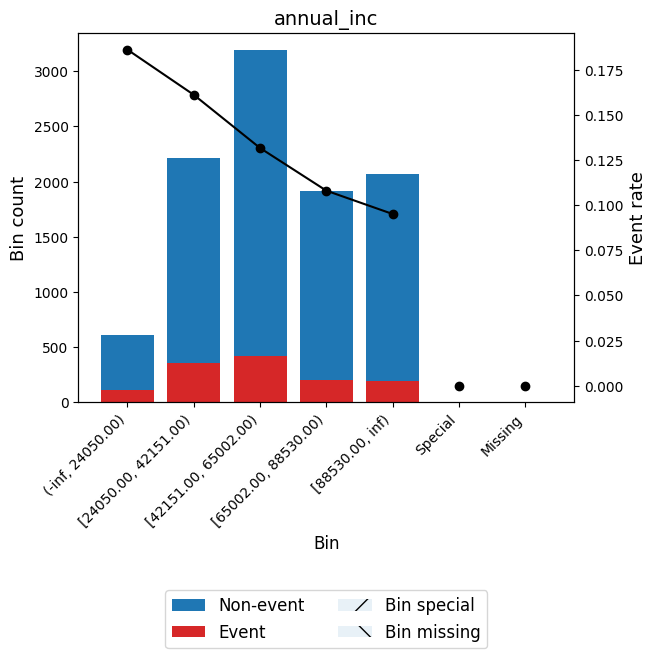

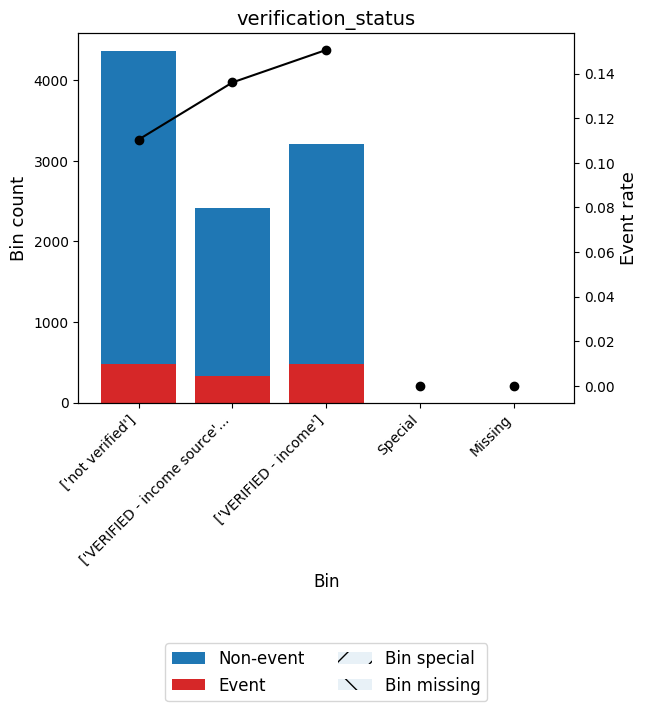

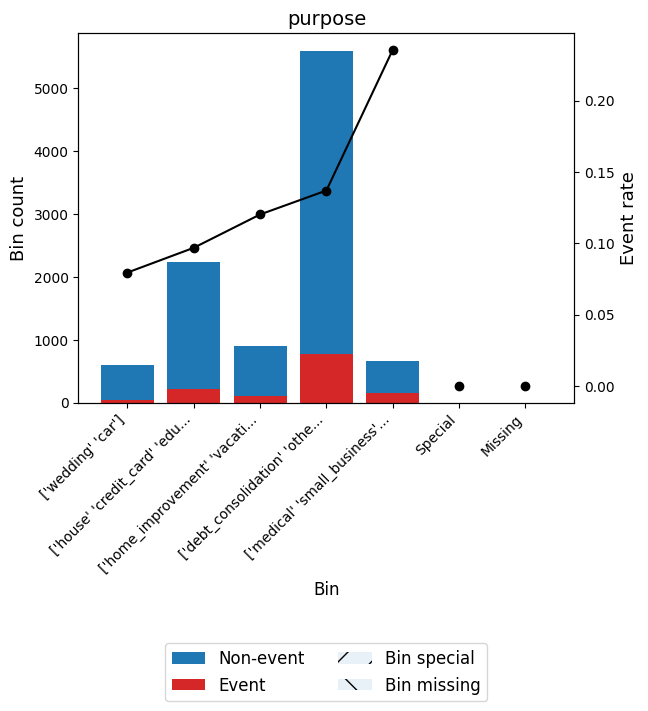

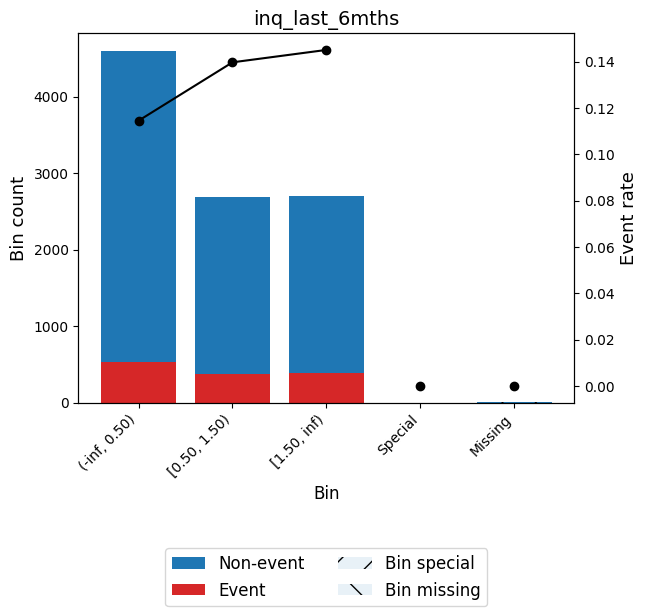

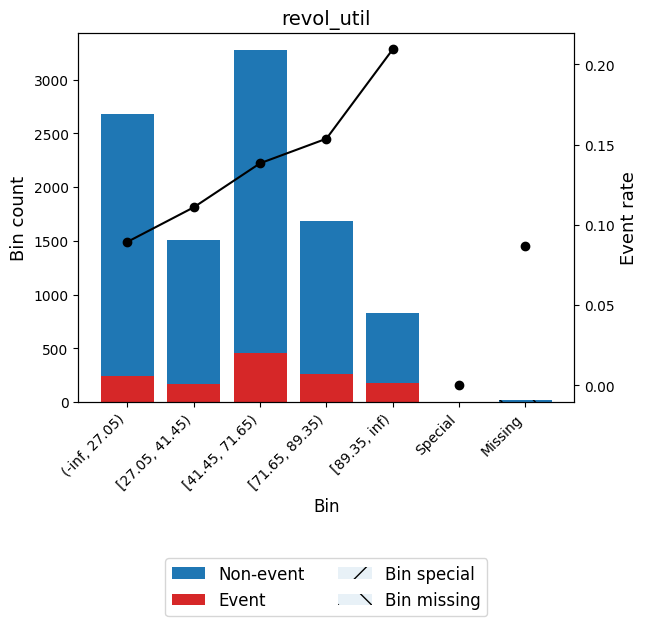

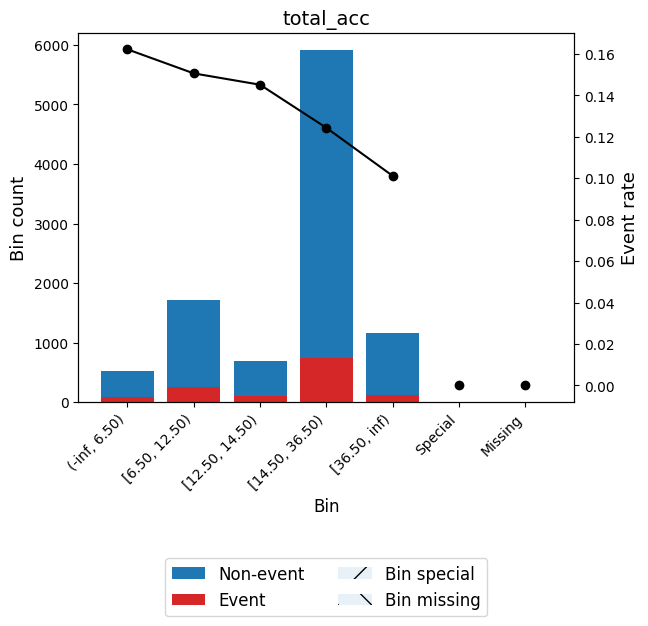

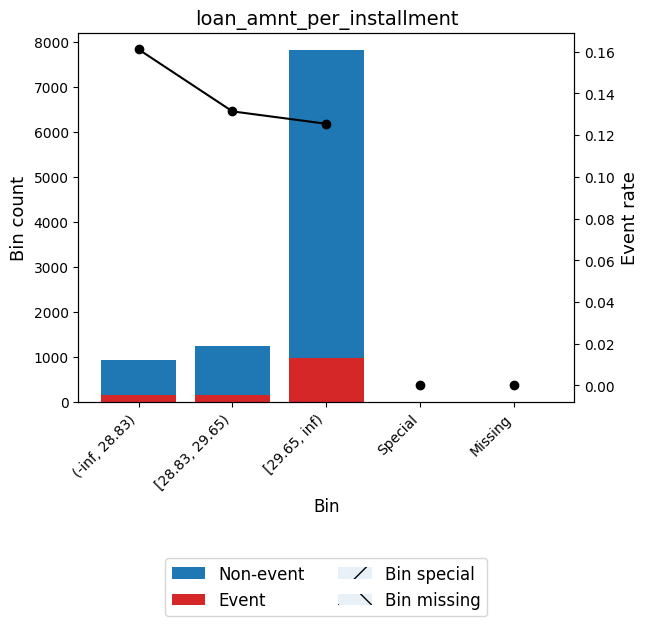

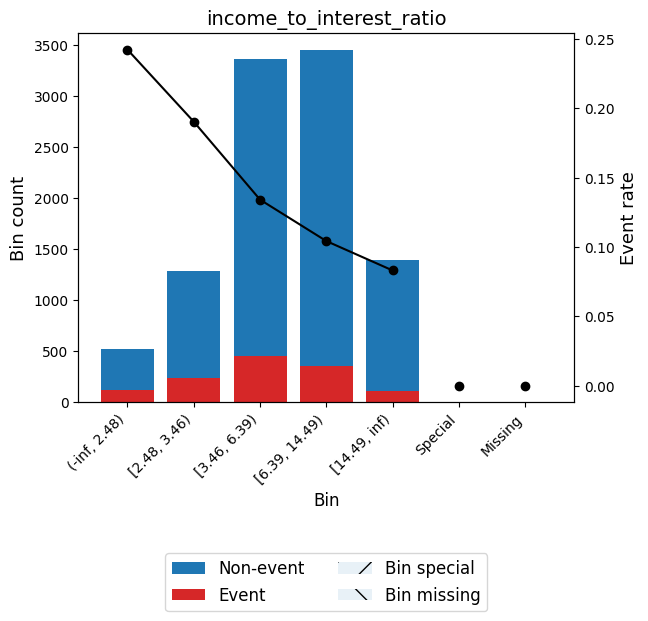

In [20]:
for col in data_final.drop(columns = ['is_bad']):
    build = binning_process.get_binned_variable(col)
    bin_df = build.binning_table.build(); bin_df
    build.binning_table.plot(metric = 'event_rate', show_bin_labels=True)

In [21]:
build_test = binning_process.get_binned_variable('loan_amnt')
bin_df = build.binning_table.build()
bin_df

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 2.48)",520,0.0520,394,126,0.242308,-0.765318,0.039824,0.004860
1,"[2.48, 3.46)",1282,0.1282,1038,244,0.190328,-0.457504,0.031648,0.003922
2,"[3.46, 6.39)",3356,0.3356,2906,450,0.134088,-0.040102,0.000548,0.000068
3,"[6.39, 14.49)",3444,0.3444,3085,359,0.104239,0.245598,0.018954,0.002363
4,"[14.49, inf)",1397,0.1397,1281,116,0.083035,0.496419,0.028585,0.003537
5,Special,0,0.0000,0,0,0.000000,0.0,0.000000,0.000000
6,Missing,1,0.0001,1,0,0.000000,0.0,0.000000,0.000000
Totals,,10000,1.0000,8705,1295,0.129500,,0.119558,0.014750


## Binning

In [22]:
data_final.head(5)

,loan_amnt,term,int_rate,grade,annual_inc,verification_status,purpose,inq_last_6mths,revol_util,total_acc,is_bad,loan_amnt_per_installment,income_to_interest_ratio
0,4000,60 months,0.0729,A,50000.0,not verified,medical,0.0,12.1,44.0,0,50.150451,12.500000
1,16000,60 months,0.1825,F,39216.0,not verified,debt_consolidation,2.0,64.0,5.0,0,39.169604,2.451000
2,8700,36 months,0.0788,A,65000.0,not verified,credit_card,0.0,0.6,8.0,0,31.967665,7.471264
3,18000,60 months,0.1149,B,57500.0,not verified,debt_consolidation,0.0,37.1,23.0,0,45.479812,3.194444
4,16000,36 months,0.1183,B,50004.0,VERIFIED - income,debt_consolidation,4.0,40.4,21.0,0,30.180138,3.125250


In [23]:
data_final_binning = binning_process.fit_transform(data_final[binning_process.variable_names], data_final['is_bad'])
data_final_binning = pd.concat([data_final_binning, data_final['is_bad']], axis=1)

data_final_binning.head(5)

,loan_amnt,term,int_rate,grade,annual_inc,verification_status,purpose,inq_last_6mths,revol_util,total_acc,loan_amnt_per_installment,income_to_interest_ratio,is_bad
0,0.149256,-0.584250,1.078203,0.810092,-0.019761,0.181547,-0.728222,0.140039,0.414956,0.279415,0.03658,0.245598,0
1,-0.113627,-0.584250,-0.451049,-0.670379,-0.256405,0.181547,-0.064651,-0.131600,-0.076787,-0.263539,0.03658,-0.765318,0
2,0.069937,0.274193,1.078203,0.810092,-0.019761,0.181547,0.327709,0.140039,0.414956,-0.175585,0.03658,0.245598,0
3,-0.113627,-0.584250,0.274596,0.226565,-0.019761,0.181547,-0.064651,0.140039,0.175551,0.046724,0.03658,-0.457504,0
4,-0.113627,0.274193,0.274596,0.226565,-0.019761,-0.175415,-0.064651,-0.131600,0.175551,0.046724,0.03658,-0.457504,0


## Export

In [24]:
joblib.dump(binning_process, "../data/artifacts/optbinning.pkl")

['../data/artifacts/optbinning.pkl']

In [25]:
data_final.to_csv("../data/interim/10K_Lending_Club_Loans_final_features.csv", index=False)

In [26]:
data_final_binning.to_csv("../data/processed/10K_Lending_Club_Loans_optbinning.csv", index=False)